In [41]:
from importlib.resources import path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, log_loss, roc_curve, classification_report, average_precision_score, mean_squared_error)
from imblearn.over_sampling import SMOTE
import time


In [2]:
training_url = "./data/adult-training.csv"
testing_url = "./data/adult-test.csv"

# merge training and testing datasets for EDA

training_df = pd.read_csv(training_url, header=None, skiprows=1 )
testing_df = pd.read_csv(testing_url, header=None, skiprows=1)

df = pd.concat([training_df, testing_df], ignore_index=True)

In [3]:
training_df.shape, testing_df.shape, df.shape

((32560, 15), (16281, 15), (48841, 15))

In [4]:
# print the head of training dataset without truncating the columns

pd.set_option('display.max_columns', None)
print(training_df.head())

   0                  1       2           3   4                    5   \
0  50   Self-emp-not-inc   83311   Bachelors  13   Married-civ-spouse   
1  38            Private  215646     HS-grad   9             Divorced   
2  53            Private  234721        11th   7   Married-civ-spouse   
3  28            Private  338409   Bachelors  13   Married-civ-spouse   
4  37            Private  284582     Masters  14   Married-civ-spouse   

                   6               7       8        9   10  11  12  \
0     Exec-managerial         Husband   White     Male   0   0  13   
1   Handlers-cleaners   Not-in-family   White     Male   0   0  40   
2   Handlers-cleaners         Husband   Black     Male   0   0  40   
3      Prof-specialty            Wife   Black   Female   0   0  40   
4     Exec-managerial            Wife   White   Female   0   0  40   

               13      14  
0   United-States   <=50K  
1   United-States   <=50K  
2   United-States   <=50K  
3            Cuba   <=50K  


In [5]:
# Set plot_flag to True if you want to generate plots
# plot_flag = True
plot_flag = False

In [6]:
def summarize_dataframe(df):
    print("--------------------------------------------------------------------")
    print("DataFrame Summary")
    print("--------------------------------------------------------------------")
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}\n")

    print("The column names in the DataFrame are:\n", df.columns.tolist())
    print("\n")
    
    print("Column Data Types:")
    print(df.dtypes)
    print("\n")

    print("Missing Values per Column:")
    print(df.isnull().sum())
    print("\n")

    print("Statistical Summary of Numerical Columns:")
    print(df.describe().T)
    print("\n")

    print("Statistical Summary of Categorical Columns:")
    print(df.describe(include=["object"]).T)
    print("\n")

    print("Unique Values per Column:")
    for col in df.columns:
        unique_values = df[col].nunique()
        print(f"Column {col}: {unique_values} unique values")
    print("--------------------------------------------------------------------")

    print("\n")

    print("The number of duplicate rows in the DataFrame:\n", df.duplicated().sum())

In [7]:
def plot_dataframe(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns

    nrows = 5
    ncols = 2

    print('--------------------------------------------------------------------')
    print('Distribution of the Numerical Columns')
    print('--------------------------------------------------------------------')
    plt.figure(figsize=(14, 5*nrows))
    
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}', fontsize=20)

        plt.xlabel(col, fontsize=20)
        plt.ylabel('Frequency', fontsize=20)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=1)
    plt.show()
    plt.close()

    print('--------------------------------------------------------------------')
    print('Boxplot of the Numerical Columns')
    print('--------------------------------------------------------------------')
    plt.figure(figsize=(28, 48))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(nrows, ncols, i)
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot of {col}', fontsize=20)
        plt.xlabel(col, fontsize=20)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=1)
    plt.show()
    plt.close()

    print('--------------------------------------------------------------------')
    print('Correlation Matrix of Numerical Columns')
    print('--------------------------------------------------------------------')
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numerical_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Matrix Heatmap', fontsize=20)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()
    plt.close()

    print('--------------------------------------------------------------------')
    print('Distribution of the Categorical Columns')
    print('--------------------------------------------------------------------')
    for i in range(0, len(categorical_cols), 6):
        subset = categorical_cols[i:i+6]
        nrows = math.ceil(len(subset) / ncols)

        plt.figure(figsize=(14, 5 * nrows))
        plt.suptitle("Categorical Column Distributions", fontsize=20, y=5)

        for j, col in enumerate(subset, 1):
            if col != 13:
                plt.subplot(nrows, ncols, j)
                sns.countplot(y=df[col])  # Flip axes for readability
                plt.title(f'Distribution of {col}', fontsize=16)
                plt.xlabel('Frequency', fontsize=14)
                plt.ylabel(col, fontsize=14)
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)

        plt.tight_layout(pad=2.0)
        plt.subplots_adjust(top=0.9, hspace=0.6, wspace=0.4)
        plt.show()
        plt.close()
    
    plt.figure(figsize=(14, 25))
    sns.countplot(y=df[13])
    plt.title('Distribution of 13', fontsize=16) 
    plt.xlabel('Frequency', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [8]:
summarize_dataframe(df)

--------------------------------------------------------------------
DataFrame Summary
--------------------------------------------------------------------
Total Rows: 48841
Total Columns: 15

The column names in the DataFrame are:
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


Column Data Types:
0      int64
1     object
2      int64
3     object
4      int64
5     object
6     object
7     object
8     object
9     object
10     int64
11     int64
12     int64
13    object
14    object
dtype: object


Missing Values per Column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
dtype: int64


Statistical Summary of Numerical Columns:
      count           mean            std      min       25%       50%  \
0   48841.0      38.643578      13.710650     17.0      28.0      37.0   
2   48841.0  189666.430786  105603.887256  12285.0  117555.0  178147.0   
4   48841.0      10.078029       2.570965      1.0       9

In [9]:
if plot_flag:
    plot_dataframe(df)

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

In [11]:
outlier_info = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR
    mask = (df[col] < lb) | (df[col] > ub)
    cnt = int(mask.sum())
    pct = cnt / len(df) * 100
    outlier_info.append((col, cnt, pct, lb, ub, mask))

In [12]:
outlier_df = pd.DataFrame([{"col": c, "count": cnt, "pct": pct} for c, cnt, pct, *_ in outlier_info]).sort_values("count", ascending=False)

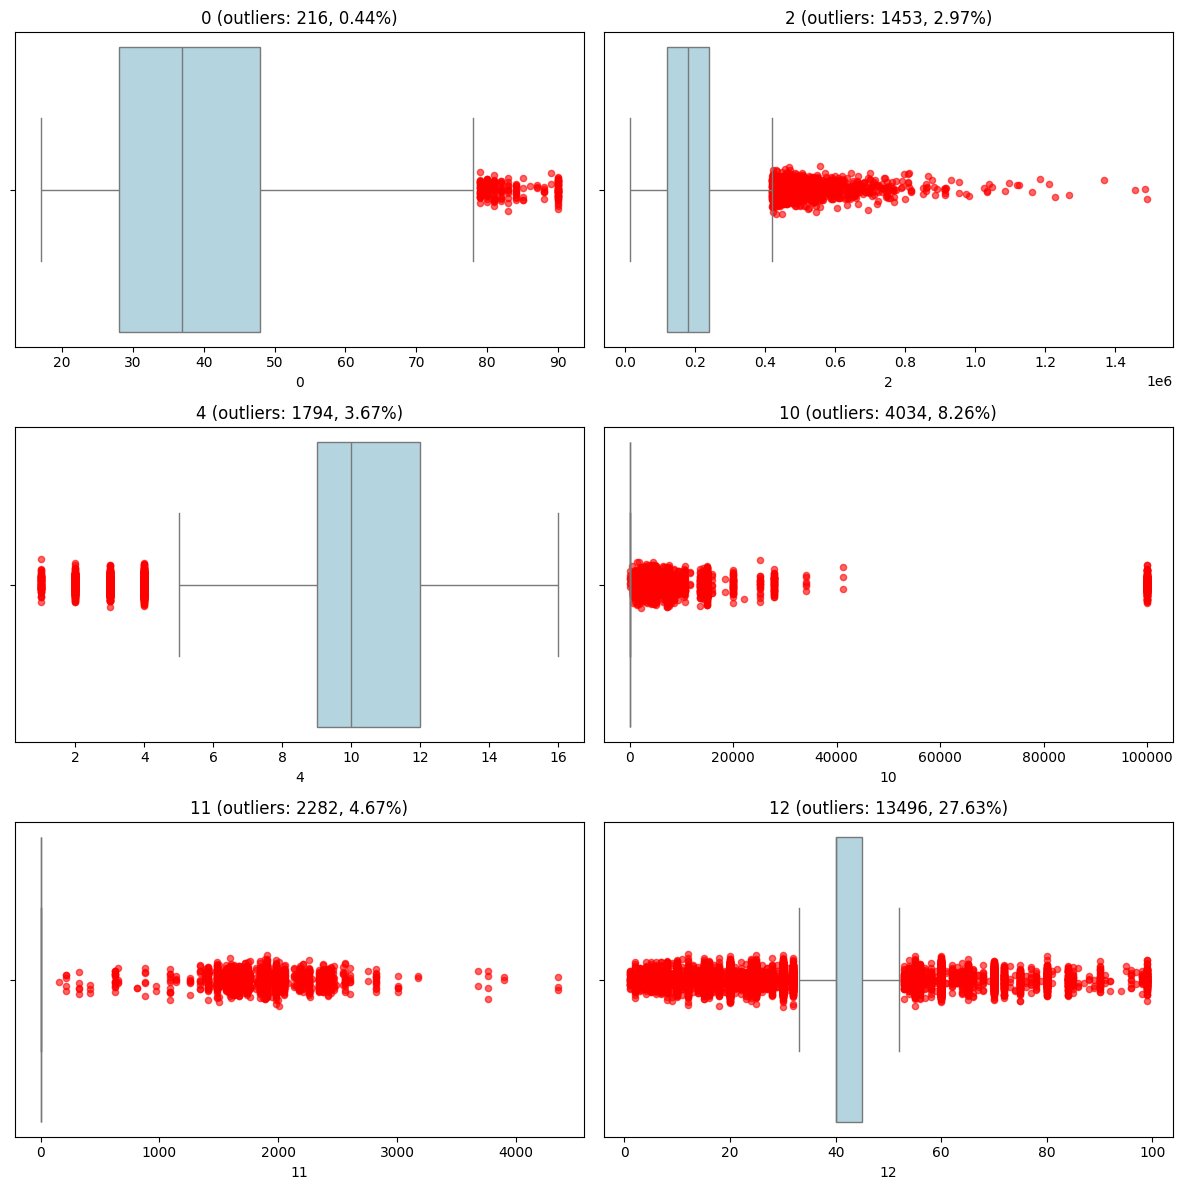

In [14]:
# Boxplots with outliers highlighted, paginate if many cols
cols = [c for c, *_ in outlier_info]
for i in range(0, len(cols), 6):
    subset = cols[i:i+6]
    n = len(subset)
    ncols = 2
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(12, 4*nrows))
    for j, col in enumerate(subset, 1):
        _, _, _, lb, ub, mask = next(x for x in outlier_info if x[0] == col)
        ax = plt.subplot(nrows, ncols, j)
        sns.boxplot(x=df[col], ax=ax, color="lightblue", showfliers=False)
        # overlay outliers
        out_vals = df.loc[mask, col].dropna().values
        if len(out_vals):
            jitter = np.random.normal(0, 0.02, size=len(out_vals))
            ax.scatter(out_vals, np.zeros_like(out_vals) + jitter, color="red", alpha=0.6, s=20, label="outliers")
        ax.set_title(f"{col} (outliers: {int(mask.sum())}, {mask.sum()/len(df)*100:.2f}%)")
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

In [15]:
## Encoding & Normalization

# there is no column names for adult dataset

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df.columns = column_names

In [16]:
# Replace "?" with NaN and drop missing rows
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

In [17]:
# Seperate numerical and categorical features
numerical_cols = ["age", "fnlwgt", "education_num",
                  "capital_gain", "capital_loss", "hours_per_week"]

categorical_cols = [col for col in df.columns if col not in numerical_cols + ["income"]]

In [18]:
# Onehot encode for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
#Normalize numerical feature using Standardscaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [66]:
#replace the <=50k. with <=50k and same for > 50k

df_encoded["income"] = df_encoded["income"].str.replace("<=50K.", "<=50K")
df_encoded["income"] = df_encoded["income"].str.replace(">50K.", ">50K")

df_encoded["income"] = df_encoded["income"].map({" <=50K": 0, " >50K": 1})

In [54]:
df_encoded["income"].unique()

array([' <=50K', ' >50K'], dtype=object)

In [ ]:
# X = df_encoded.drop("income", axis=1)
# y = df_encoded["income"].map({" <=50K": 0, " >50K": 1})

# print("Encoding & normalization completed.")
# print("Final feature matrix shape:" , X.shape)

Encoding & normalization completed.
Final feature matrix shape: (48841, 100)


In [ ]:
def modelsToRun(X_train, X_test, y_train, y_test, results_per_dataframe, df_name):
  global roc_curves

  print(f'The train length are {len(X_train), len(y_train)}')
  print(f'The test length are {len(X_test), len(y_test)}')

  models = {
      "Logistic Regression": LogisticRegression(random_state=42, max_iter=10000),
      "KNN": KNeighborsClassifier(),
      "Random Forest": RandomForestClassifier(random_state=42),
      "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
      "SVM": SVC(probability=True, random_state=42)
  }

  roc_curves = {}

  # Set up cross-validation
  cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
  scoring = ['roc_auc', 'f1', 'average_precision', 'accuracy']

  print("Model training and evaluation loop started...\n")
  for model_name, model in models.items():
      print(f"Model: {model_name}")
      print(f"Algorithm: {model_name}")

      # Fit on training data
      start_time = time.time()
      model.fit(X_train, y_train)
      train_time = time.time() - start_time
      print(f"Training Time: {train_time:.2f} seconds")

      # Predict on test data
      start_time = time.time()
      y_test_pred = model.predict(X_test)
      prediction_time = time.time() - start_time
      print(f"Prediction Time: {prediction_time:.2f} seconds")
      total_time = train_time + prediction_time
      print(f"Total Time: {total_time:.2f} seconds")

      # Probabilities for AUC
      y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

      # Evaluation
      accuracy = accuracy_score(y_test, y_test_pred)
      precision = precision_score(y_test, y_test_pred, pos_label=1)
      recall = recall_score(y_test, y_test_pred, pos_label=1)
      f1 = f1_score(y_test, y_test_pred)
      cm = confusion_matrix(y_test, y_test_pred)
      mse = mean_squared_error(y_test, y_test_pred)
      logloss = log_loss(y_test, y_test_prob) if y_test_prob is not None else None
      roc_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

      if y_test_prob is not None:
          fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
          roc_curves[model_name] = (fpr, tpr, roc_auc)

      # Perform cross-validation on combined data (or just training set if preferred)
      scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

      print(f"\n{model_name} Test Set Classification Report:\n{classification_report(y_test, y_test_pred)}")
      print("Confusion Matrix:\n", cm)
      print("ROC AUC (Test):", roc_auc)
      print("F1 Score (Test):", f1)
      print("Average Precision (Test):", average_precision_score(y_test, y_test_prob) if y_test_prob is not None else None)
      print("Accuracy (Test):", accuracy)
      print("---------------------------------------\n")

      feature_importance = None
      feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature_{i}' for i in range(X_train.shape[1])]
      # Tree-based models
      if hasattr(model, 'feature_importances_'):

          importance_values = model.feature_importances_
          feature_importance = dict(zip(feature_names, importance_values))
      # Linear models
      elif hasattr(model, 'coef_'):

          try:
              importance_values = model.coef_[0]
              feature_importance = dict(zip(feature_names, importance_values))
          except Exception as e:
              print(f"Could not extract coef_ from {model_name}: {e}")

      # Store results
      results_per_dataframe[df_name][model_name] = {
          "Accuracy": accuracy,
          "Precision": precision,
          "Recall": recall,
          "F1 Score": f1,
          "Confusion Matrix": cm,
          "ROC-AUC Score": roc_auc,
          "Mean Squared Error": mse,
          "Log Loss": logloss,
          "Training Time (s)": train_time,
          "Prediction Time (s)": prediction_time,
          "Total Time (s)": total_time,
          "ROC Curves": roc_curves.get(model_name),
          "y_test": y_test,
          "y_test_pred": y_test_pred,
          "Feature Importance": feature_importance,
          "Cross-Validation Scores": scores,
          "CV Mean ROC AUC": scores['test_roc_auc'].mean(),
          "CV Mean F1": scores['test_f1'].mean(),
          "CV Mean Accuracy": scores['test_accuracy'].mean(),
          "CV Mean Average Precision": scores['test_average_precision'].mean()
      }

      print(f"\nCross-Validation Summary for {model_name}:")
      print(f"ROC AUC: {scores['test_roc_auc'].mean():.4f}")
      print(f"F1 Score: {scores['test_f1'].mean():.4f}")
      print(f"Accuracy: {scores['test_accuracy'].mean():.4f}")
      print(f"Avg Precision: {scores['test_average_precision'].mean():.4f}")
      print('------------------------------------\n')


In [105]:
results_per_dataframe = {"Original": {}, "SMOTE": {}}
target = "income"

In [106]:
def smoteBalancedData(df):
  copy_df = df.copy()

  X = copy_df.drop(columns=[target])
  y = copy_df[target]

  smote = SMOTE(random_state=42)
  resampled_X, resampled_y = smote.fit_resample(X, y)

  return pd.concat([resampled_X, resampled_y], axis=1)

In [107]:
def dataSplitTrainTest(df, target_column=target, test_size=0.3, random_state=42):
  copy_df = df.copy()

  X = copy_df.drop(columns=[target_column])
  y = copy_df[target_column]

  train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

  return train_X, train_y, test_X, test_y


In [108]:
ori_train_X, ori_train_y, ori_test_X, ori_test_y = dataSplitTrainTest(df_encoded, target_column=target)

In [109]:
smote_df = smoteBalancedData(df_encoded)
smote_train_X, smote_train_y, smote_test_X, smote_test_y = dataSplitTrainTest(smote_df, target_column=target)

In [110]:
dataframes_to_run = {"Original": (ori_train_X, ori_train_y, ori_test_X, ori_test_y),
                         "SMOTE": (smote_train_X, smote_train_y, smote_test_X, smote_test_y)}

In [ ]:
for df_name in dataframes_to_run.keys():

    X_train, y_train, X_test, y_test = dataframes_to_run[df_name]
    print("--------------------------------------------------")
    print(f"\nRunning models on {df_name} dataset:")
    modelsToRun(X_train, X_test, y_train, y_test, results_per_dataframe, df_name)
    print("--------------------------------------------------\n")

--------------------------------------------------

Running models on Original dataset:
The train length are (34188, 34188)
The test length are (14653, 14653)
Model training and evaluation loop started...

Model: Logistic Regression
Algorithm: Logistic Regression
Training Time: 0.52 seconds
Prediction Time: 0.01 seconds
Total Time: 0.53 seconds

Logistic Regression Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     11147
           1       0.74      0.60      0.66      3506

    accuracy                           0.85     14653
   macro avg       0.81      0.77      0.78     14653
weighted avg       0.85      0.85      0.85     14653

Confusion Matrix:
 [[10398   749]
 [ 1402  2104]]
ROC AUC (Test): 0.9059586992087434
F1 Score (Test): 0.6617392671803742
Average Precision (Test): 0.7649138100800665
Accuracy (Test): 0.8532041220227939
---------------------------------------

df_name: Original, model_name:

In [ ]:
# Save results_per_dataframe to a file for later analysis
import pickle

with open("results_per_dataframe.pkl", "wb") as f:
    pickle.dump(results_per_dataframe, f)